In [43]:
# run this cell once to install dependencies
!pip install "numpy<2" shap lime tensorflow scikit_surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit_surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554973 sha256=998b88b4387465f2e18a258bccab2d564881abd4f370f2e7f09bfada3f514c2a
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit_surprise


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

# scipy
from scipy.sparse.linalg import svds
from scipy.stats import pearsonr

print('All imports done!')

All imports done!


## Loading the Dataset

Download from: https://grouplens.org/datasets/movielens/  
We are using **ml-latest-small** (100k ratings, manageable size).  
Place the extracted folder in the same directory as this notebook.

In [3]:
import os
import zipfile
import urllib.request

DATASET_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_FILE    = "ml-latest-small.zip"
FOLDER      = "ml-latest-small"

if os.path.exists(FOLDER):
    print(f"'{FOLDER}' already exists — skipping download.")
else:
    print("Downloading MovieLens dataset...")

    def show_progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        pct = min(downloaded / total_size * 100, 100)
        print(f"\r  {pct:.1f}%  ({downloaded // 1024} KB / {total_size // 1024} KB)", end="", flush=True)

    urllib.request.urlretrieve(DATASET_URL, ZIP_FILE, reporthook=show_progress)
    print("\nDownload complete. Extracting...")

    with zipfile.ZipFile(ZIP_FILE, 'r') as z:
        z.extractall(".")

    os.remove(ZIP_FILE)
    print(f"Done! Dataset ready in './{FOLDER}/'")

# quick sanity check
for f in ["movies.csv", "ratings.csv", "tags.csv"]:
    path = os.path.join(FOLDER, f)
    size = os.path.getsize(path) // 1024
    print(f"  {f:15s}  {size} KB")

  100.0%  (960 KB / 955 KB)
Download complete. Extracting...
Done! Dataset ready in './ml-latest-small/'
  movies.csv       482 KB
  ratings.csv      2425 KB
  tags.csv         115 KB


In [4]:
movies  = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')
tags    = pd.read_csv('ml-latest-small/tags.csv')

print('movies shape :', movies.shape)
print('ratings shape:', ratings.shape)
print('tags shape   :', tags.shape)

movies shape : (9742, 3)
ratings shape: (100836, 4)
tags shape   : (3683, 4)


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
print('unique users  :', ratings['userId'].nunique())
print('unique movies :', ratings['movieId'].nunique())
print('rating range  :', ratings['rating'].min(), 'to', ratings['rating'].max())
print()
print('rating distribution:')
print(ratings['rating'].value_counts().sort_index())

unique users  : 610
unique movies : 9724
rating range  : 0.5 to 5.0

rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


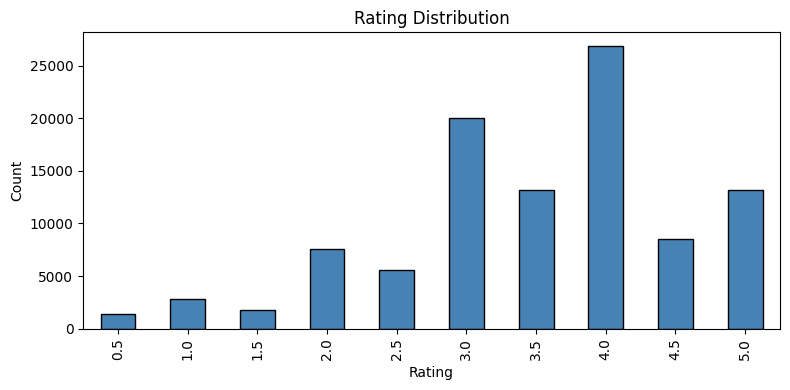

In [8]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# clean genres: replace pipe with space so TF-IDF treats each genre as a separate word
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)
movies['genres_clean'] = movies['genres_clean'].str.replace('(no genres listed)', '', regex=False)

# extract year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('float')

movies[['title', 'genres', 'genres_clean', 'year']].head(8)

,title,genres,genres_clean,year
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy,1995.0
1,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy,1995.0
2,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance,1995.0
3,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy Drama Romance,1995.0
4,Father of the Bride Part II (1995),Comedy,Comedy,1995.0
5,Heat (1995),Action|Crime|Thriller,Action Crime Thriller,1995.0
6,Sabrina (1995),Comedy|Romance,Comedy Romance,1995.0
7,Tom and Huck (1995),Adventure|Children,Adventure Children,1995.0


---
# Part 1: Content-Based Filtering

Content-based filtering recommends movies similar to what a user already liked, purely based on movie features like genres.

## Task 1: TF-IDF Based Recommendation

Each movie is described by its genres. We convert that into a TF-IDF vector and find movies with similar vectors.

In [10]:
# Step 1: build TF-IDF matrix over genres
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'].fillna(''))

print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('Genre tokens found :', tfidf.get_feature_names_out())

TF-IDF matrix shape: (9742, 21)
Genre tokens found : ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'horror' 'imax' 'musical'
 'mystery' 'noir' 'romance' 'sci' 'thriller' 'war' 'western']


In [11]:
# Step 2: cosine similarity between all movie pairs
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print('Cosine similarity matrix shape:', cosine_sim.shape)
print('Sample (first 5x5):')
print(np.round(cosine_sim[:5, :5], 3))

Cosine similarity matrix shape: (9742, 9742)
Sample (first 5x5):
[[1.    0.814 0.153 0.135 0.268]
 [0.814 1.    0.    0.    0.   ]
 [0.153 0.    1.    0.885 0.571]
 [0.135 0.    0.885 1.    0.505]
 [0.268 0.    0.571 0.505 1.   ]]


In [12]:
# reverse index: title -> row number in movies dataframe
movie_indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def recommend_by_title(title, n=5):
    if title not in movie_indices:
        print(f"'{title}' not found. Check the exact title.")
        return None

    idx = movie_indices[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)

    # skip index 0 (the movie itself, sim=1.0)
    sim_scores = sim_scores[1:n+1]

    idxs   = [s[0] for s in sim_scores]
    scores = [round(s[1], 4) for s in sim_scores]

    result = movies.iloc[idxs][['title', 'genres']].copy()
    result['similarity'] = scores

    print(f"\nTop {n} movies similar to: '{title}'")
    print(result.to_string(index=False))
    return result

In [13]:
rec1 = recommend_by_title('Toy Story (1995)')


Top 5 movies similar to: 'Toy Story (1995)'
                                         title                                      genres  similarity
                                   Antz (1998) Adventure|Animation|Children|Comedy|Fantasy         1.0
                            Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy         1.0
Adventures of Rocky and Bullwinkle, The (2000) Adventure|Animation|Children|Comedy|Fantasy         1.0
              Emperor's New Groove, The (2000) Adventure|Animation|Children|Comedy|Fantasy         1.0
                         Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy         1.0


In [14]:
rec2 = recommend_by_title('Inception (2010)')


Top 5 movies similar to: 'Inception (2010)'
                title                                     genres  similarity
      Watchmen (2009)  Action|Drama|Mystery|Sci-Fi|Thriller|IMAX      0.9450
       Super 8 (2011)               Mystery|Sci-Fi|Thriller|IMAX      0.8814
       RoboCop (2014)                   Action|Crime|Sci-Fi|IMAX      0.8496
  Strange Days (1995) Action|Crime|Drama|Mystery|Sci-Fi|Thriller      0.8412
V for Vendetta (2006)                Action|Sci-Fi|Thriller|IMAX      0.8322


In [15]:
rec3 = recommend_by_title('Fargo (1996)')


Top 5 movies similar to: 'Fargo (1996)'
                                                title                      genres  similarity
                                         Fargo (1996) Comedy|Crime|Drama|Thriller         1.0
                                       Freeway (1996) Comedy|Crime|Drama|Thriller         1.0
Man Bites Dog (C'est arrivé près de chez vous) (1992) Comedy|Crime|Drama|Thriller         1.0
                           Beautiful Creatures (2000) Comedy|Crime|Drama|Thriller         1.0
               Confessions of a Dangerous Mind (2002) Comedy|Crime|Drama|Thriller         1.0


In [16]:
# EXPERIMENT: what if we also include user tags as additional features?
# Tags like 'based on a book' or 'twist ending' can improve similarity.

tag_strings = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
tag_strings.columns = ['movieId', 'tag_string']

movies_ext = movies.merge(tag_strings, on='movieId', how='left')
movies_ext['combined'] = movies_ext['genres_clean'].fillna('') + ' ' + movies_ext['tag_string'].fillna('')

tfidf_ext = TfidfVectorizer(stop_words='english', min_df=2)
tfidf_matrix_ext = tfidf_ext.fit_transform(movies_ext['combined'])
cosine_sim_ext   = cosine_similarity(tfidf_matrix_ext, tfidf_matrix_ext)

movie_indices_ext = pd.Series(movies_ext.index, index=movies_ext['title']).drop_duplicates()

def recommend_extended(title, n=5):
    if title not in movie_indices_ext:
        print(f"'{title}' not found")
        return None
    idx = movie_indices_ext[title]
    sim_scores = sorted(enumerate(cosine_sim_ext[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    idxs   = [s[0] for s in sim_scores]
    scores = [round(s[1], 4) for s in sim_scores]
    result = movies_ext.iloc[idxs][['title', 'genres']].copy()
    result['similarity'] = scores
    print(f"\n[Genres + Tags] Similar to '{title}':")
    print(result.to_string(index=False))
    return result

# compare with genres-only
print('--- Genres only ---')
recommend_by_title('Toy Story (1995)')
print('\n--- Genres + Tags ---')
recommend_extended('Toy Story (1995)')

--- Genres only ---

Top 5 movies similar to: 'Toy Story (1995)'
                                         title                                      genres  similarity
                                   Antz (1998) Adventure|Animation|Children|Comedy|Fantasy         1.0
                            Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy         1.0
Adventures of Rocky and Bullwinkle, The (2000) Adventure|Animation|Children|Comedy|Fantasy         1.0
              Emperor's New Groove, The (2000) Adventure|Animation|Children|Comedy|Fantasy         1.0
                         Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy         1.0

--- Genres + Tags ---

[Genres + Tags] Similar to 'Toy Story (1995)':
                           title                                      genres  similarity
            Bug's Life, A (1998)         Adventure|Animation|Children|Comedy      0.8622
              Toy Story 2 (1999) Adventure|Animation|Children|Comedy

,title,genres,similarity
1757,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8622
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.6440
7039,Up (2009),Adventure|Animation|Children|Drama,0.3879
8695,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.3677
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.3579


## Task 2: User-Profile-Based Content Recommender

Build a user profile by taking a weighted average of the TF-IDF vectors of movies they have rated.  
Higher-rated movies contribute more weight to the profile.

In [17]:
# movieId -> row index in movies dataframe
movieid_to_idx = pd.Series(movies.index, index=movies['movieId'])

def build_user_profile(user_id):
    """
    Compute user profile vector as weighted average of TF-IDF vectors.
    Formula: P_u = sum(r_um * f_m) / sum(r_um)
    """
    user_ratings = ratings[ratings['userId'] == user_id]
    user_ratings = user_ratings[user_ratings['movieId'].isin(movieid_to_idx.index)]

    if user_ratings.empty:
        return None

    movie_idxs    = movieid_to_idx[user_ratings['movieId'].values].values
    user_tfidf    = tfidf_matrix[movie_idxs]          # (num_rated, num_features)
    weights       = user_ratings['rating'].values.reshape(-1, 1)

    weighted_sum  = np.array(user_tfidf.multiply(weights).sum(axis=0))
    total_weight  = weights.sum()
    profile       = weighted_sum / total_weight       # normalize

    return profile   # shape: (1, num_features)

In [18]:
def recommend_for_user(user_id, n=10, exclude_seen=True):
    profile = build_user_profile(user_id)
    if profile is None:
        print('User not found or has no ratings.')
        return None

    sims   = cosine_similarity(profile, tfidf_matrix).flatten()
    result = movies.copy()
    result['score'] = sims

    if exclude_seen:
        watched     = ratings[ratings['userId'] == user_id]['movieId'].values
        watched_idx = movieid_to_idx[movieid_to_idx.index.isin(watched)].values
        result      = result.drop(index=watched_idx, errors='ignore')

    top = result.nlargest(n, 'score')[['title', 'genres', 'score']]
    print(f"\nTop {n} recommendations for User {user_id}:")
    print(top.to_string(index=False))
    return top

In [19]:
recs_u1 = recommend_for_user(1, n=10)


Top 10 recommendations for User 1:
                                        title                                          genres    score
        Dragonheart 2: A New Beginning (2000)  Action|Adventure|Comedy|Drama|Fantasy|Thriller 0.791026
                    Hunting Party, The (2007)          Action|Adventure|Comedy|Drama|Thriller 0.773645
                             Flashback (1990)             Action|Adventure|Comedy|Crime|Drama 0.773089
               The Great Train Robbery (1978)             Action|Adventure|Comedy|Crime|Drama 0.773089
       Charlie's Angels: Full Throttle (2003)          Action|Adventure|Comedy|Crime|Thriller 0.760503
                      After the Sunset (2004)          Action|Adventure|Comedy|Crime|Thriller 0.760503
Diamond Arm, The (Brilliantovaya ruka) (1968)          Action|Adventure|Comedy|Crime|Thriller 0.760503
                               Machete (2010)          Action|Adventure|Comedy|Crime|Thriller 0.760503
                          Maximum Rid

In [20]:
# what did user 1 actually rate?
u1_rated = ratings[ratings['userId'] == 1].merge(movies, on='movieId')
print('User 1 top rated movies:')
print(u1_rated[['title', 'genres', 'rating']].sort_values('rating', ascending=False).head(8).to_string(index=False))

User 1 top rated movies:
                                    title                       genres  rating
             M*A*S*H (a.k.a. MASH) (1970)             Comedy|Drama|War     5.0
                         Excalibur (1981)            Adventure|Fantasy     5.0
Indiana Jones and the Last Crusade (1989)             Action|Adventure     5.0
              Pink Floyd: The Wall (1982)                Drama|Musical     5.0
             From Russia with Love (1963)    Action|Adventure|Thriller     5.0
                        Goldfinger (1964)    Action|Adventure|Thriller     5.0
                  Dirty Dozen, The (1967)             Action|Drama|War     5.0
                Gulliver's Travels (1939) Adventure|Animation|Children     5.0


In [21]:
def precision_recall_at_k(user_id, k=10, threshold=4.0):
    """
    Precision@K = how many of top-K recommendations were actually rated >= threshold.
    Recall@K    = how many of the highly-rated movies did we capture in top-K.
    """
    relevant = set(ratings[(ratings['userId'] == user_id) & (ratings['rating'] >= threshold)]['movieId'].values)
    if not relevant:
        return 0.0, 0.0

    profile = build_user_profile(user_id)
    if profile is None:
        return 0.0, 0.0

    sims       = cosine_similarity(profile, tfidf_matrix).flatten()
    top_k_idx  = np.argsort(sims)[::-1][:k]
    recommended = set(movies.iloc[top_k_idx]['movieId'].values)

    hits      = len(recommended & relevant)
    precision = hits / k
    recall    = hits / len(relevant)

    return precision, recall


print('Evaluating content-based user profiles:')
for uid in [1, 5, 10, 20, 50]:
    p, r = precision_recall_at_k(uid, k=10)
    print(f'  User {uid:3d}  ->  Precision@10: {p:.3f},  Recall@10: {r:.3f}')

Evaluating content-based user profiles:
  User   1  ->  Precision@10: 0.000,  Recall@10: 0.000
  User   5  ->  Precision@10: 0.000,  Recall@10: 0.000
  User  10  ->  Precision@10: 0.000,  Recall@10: 0.000
  User  20  ->  Precision@10: 0.500,  Recall@10: 0.041
  User  50  ->  Precision@10: 0.000,  Recall@10: 0.000


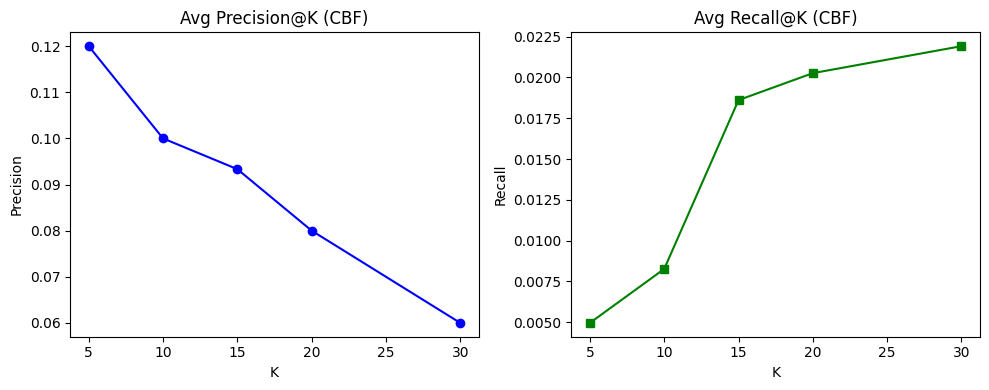

In [22]:
# EXPERIMENT: how do P@K and R@K change with different K values?

k_vals       = [5, 10, 15, 20, 30]
test_users   = [1, 5, 10, 20, 50]
avg_p, avg_r = [], []

for k in k_vals:
    ps, rs = [], []
    for uid in test_users:
        p, r = precision_recall_at_k(uid, k=k)
        ps.append(p); rs.append(r)
    avg_p.append(np.mean(ps))
    avg_r.append(np.mean(rs))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_vals, avg_p, marker='o', color='blue')
axes[0].set_title('Avg Precision@K (CBF)'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Precision')
axes[1].plot(k_vals, avg_r, marker='s', color='green')
axes[1].set_title('Avg Recall@K (CBF)'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Recall')
plt.tight_layout(); plt.show()

---
# Part 2: Collaborative Filtering


Instead of using movie features, CF finds users or items that behave similarly and uses that to predict ratings.

In [23]:
# Filter to active users (>= 50 ratings) and popular movies (>= 20 ratings)
# This keeps the matrix manageable and reduces noise

active_users    = ratings['userId'].value_counts()
popular_movies  = ratings['movieId'].value_counts()

active_users   = active_users[active_users   >= 50].index
popular_movies = popular_movies[popular_movies >= 20].index

filtered = ratings[
    ratings['userId'].isin(active_users) &
    ratings['movieId'].isin(popular_movies)
]

print(f'Filtered: {filtered["userId"].nunique()} users, {filtered["movieId"].nunique()} movies')

# user-movie matrix: rows=users, cols=movies, values=ratings (0=not rated)
user_movie_matrix = filtered.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
print('User-Movie matrix shape:', user_movie_matrix.shape)

Filtered: 385 users, 1297 movies
User-Movie matrix shape: (385, 1297)


## Task 3: User-Based Collaborative Filtering

In [24]:
# Pearson correlation is better than cosine here because it centers each user's ratings.
# A user who always gives 5s and one who always gives 3s may have similar taste —
# Pearson handles this, cosine does not.

def pearson_user_sim(matrix):
    n = matrix.shape[0]
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            u1, u2 = matrix.iloc[i].values, matrix.iloc[j].values
            mask   = (u1 != 0) & (u2 != 0)
            if mask.sum() < 2:
                sim[i, j] = sim[j, i] = 0
            else:
                corr, _ = pearsonr(u1[mask], u2[mask])
                sim[i, j] = sim[j, i] = 0 if np.isnan(corr) else corr
    return pd.DataFrame(sim, index=matrix.index, columns=matrix.index)


# using first 100 users for speed (full version would take longer)
sample_users = user_movie_matrix.index[:100]
matrix_sample = user_movie_matrix.loc[sample_users]

print(f'Computing Pearson similarity for {len(sample_users)} users...')
user_sim = pearson_user_sim(matrix_sample)
print('Done. Shape:', user_sim.shape)

Computing Pearson similarity for 100 users...
Done. Shape: (100, 100)


In [25]:
def predict_ub(user_id, movie_id, k=10):
    if user_id not in user_sim.index or movie_id not in matrix_sample.columns:
        return np.nan

    # top-k most similar users who rated this movie
    sims     = user_sim[user_id].drop(user_id).sort_values(ascending=False)
    rated    = sims[matrix_sample[movie_id][sims.index] != 0]
    top_k    = rated.head(k)

    if top_k.empty or top_k.abs().sum() == 0:
        return np.nan

    neighbor_ratings = matrix_sample.loc[top_k.index, movie_id]
    predicted        = np.dot(top_k.values, neighbor_ratings.values) / np.abs(top_k.values).sum()
    return predicted


def recommend_ub(user_id, n=10, k=10):
    if user_id not in matrix_sample.index:
        print('User not in sample.'); return None

    unrated     = matrix_sample.columns[matrix_sample.loc[user_id] == 0]
    preds       = {}
    for mid in unrated:
        p = predict_ub(user_id, mid, k=k)
        if not np.isnan(p):
            preds[mid] = p

    top         = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:n]
    result      = pd.DataFrame(top, columns=['movieId', 'pred_rating'])
    result      = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result['pred_rating'] = result['pred_rating'].round(2)

    print(f'\nUser-Based CF: Top {n} for User {user_id}')
    print(result[['title', 'genres', 'pred_rating']].to_string(index=False))
    return result


ub_recs = recommend_ub(sample_users[0], n=10)


User-Based CF: Top 10 for User 1
                                                    title                     genres  pred_rating
                               Terms of Endearment (1983)               Comedy|Drama         5.00
                                           Solaris (2002)       Drama|Romance|Sci-Fi         5.00
                                             Shine (1996)              Drama|Romance         4.94
                                    Doctor Zhivago (1965)          Drama|Romance|War         4.91
                                 Shaun of the Dead (2004)              Comedy|Horror         4.87
                                   West Side Story (1961)      Drama|Musical|Romance         4.75
   Wallace & Gromit: The Best of Aardman Animation (1996) Adventure|Animation|Comedy         4.73
                                            Casino (1995)                Crime|Drama         4.67
Lord of the Rings: The Fellowship of the Ring, The (2001)          Adventure|Fantasy

In [26]:
# Evaluate RMSE for user-based CF
def eval_ub_rmse(k=10, n_test=50):
    errors = []
    for _, row in filtered.sample(300, random_state=42).iterrows():
        uid, mid, true_r = row['userId'], row['movieId'], row['rating']
        if uid in matrix_sample.index and mid in matrix_sample.columns:
            pred = predict_ub(uid, mid, k=k)
            if not np.isnan(pred):
                errors.append((true_r - pred) ** 2)
        if len(errors) >= n_test:
            break
    if errors:
        rmse = np.sqrt(np.mean(errors))
        print(f'  k={k:2d}  ->  RMSE = {rmse:.4f}  (over {len(errors)} predictions)')
        return rmse
    return None

print('User-Based CF RMSE at different K values:')
ub_rmse_vals = []
k_test_vals  = [5, 10, 15, 20]
for k in k_test_vals:
    ub_rmse_vals.append(eval_ub_rmse(k=k, n_test=40))

User-Based CF RMSE at different K values:
  k= 5  ->  RMSE = 0.9760  (over 40 predictions)
  k=10  ->  RMSE = 1.3078  (over 40 predictions)
  k=15  ->  RMSE = 1.5139  (over 40 predictions)
  k=20  ->  RMSE = 1.7182  (over 40 predictions)


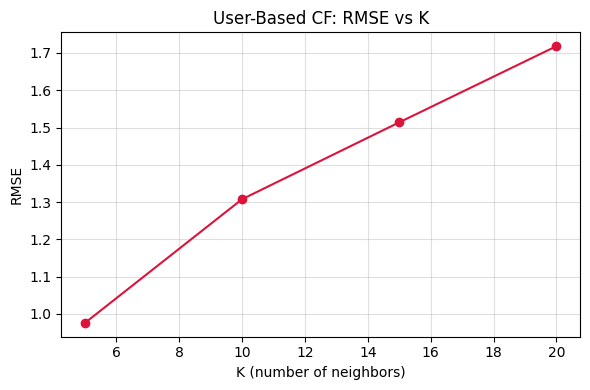

In [27]:
# EXPERIMENT: plot RMSE vs K
plt.figure(figsize=(6, 4))
plt.plot(k_test_vals, ub_rmse_vals, marker='o', color='crimson')
plt.title('User-Based CF: RMSE vs K')
plt.xlabel('K (number of neighbors)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Task 4: Item-Based Collaborative Filtering

In [28]:
# item-item cosine similarity: transpose so rows=movies, columns=users
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

item_sim_mat = cos_sim(matrix_sample.T)   # (movies x movies)
item_sim_df  = pd.DataFrame(item_sim_mat, index=matrix_sample.columns, columns=matrix_sample.columns)

print('Item similarity matrix shape:', item_sim_df.shape)

Item similarity matrix shape: (1297, 1297)


In [29]:
def predict_ib(user_id, movie_id, k=10):
    """
    Predict rating for movie_id by user_id using item-based CF.
    Find movies similar to movie_id that the user has already rated.
    """
    if user_id not in matrix_sample.index or movie_id not in item_sim_df.index:
        return np.nan

    user_ratings = matrix_sample.loc[user_id]
    rated        = user_ratings[user_ratings != 0]
    if rated.empty:
        return np.nan

    # similarity of target movie to all rated movies, top-k
    sims = item_sim_df.loc[movie_id, rated.index].sort_values(ascending=False)[:k]
    if sims.abs().sum() == 0:
        return np.nan

    predicted = np.dot(sims.values, rated[sims.index].values) / np.abs(sims.values).sum()
    return predicted


def recommend_ib(user_id, n=10, k=10):
    if user_id not in matrix_sample.index:
        print('User not in sample.'); return None

    unrated = matrix_sample.columns[matrix_sample.loc[user_id] == 0]
    preds   = {}
    for mid in unrated:
        p = predict_ib(user_id, mid, k=k)
        if not np.isnan(p):
            preds[mid] = p

    top    = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:n]
    result = pd.DataFrame(top, columns=['movieId', 'pred_rating'])
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result['pred_rating'] = result['pred_rating'].round(2)

    print(f'\nItem-Based CF: Top {n} for User {user_id}')
    print(result[['title', 'genres', 'pred_rating']].to_string(index=False))
    return result


ib_recs = recommend_ib(sample_users[0], n=10)


Item-Based CF: Top 10 for User 1
                                                     title                                  genres  pred_rating
For a Few Dollars More (Per qualche dollaro in più) (1965)           Action|Drama|Thriller|Western         5.00
                              Bourne Supremacy, The (2004)                   Action|Crime|Thriller         5.00
        Howl's Moving Castle (Hauru no ugoku shiro) (2004)     Adventure|Animation|Fantasy|Romance         5.00
                                       Gosford Park (2001)                    Comedy|Drama|Mystery         5.00
                                      The Machinist (2004)                  Drama|Mystery|Thriller         5.00
                                           Sin City (2005) Action|Crime|Film-Noir|Mystery|Thriller         5.00
                                           Iron Man (2008)                 Action|Adventure|Sci-Fi         5.00
                                      Avengers, The (2012)            

In [30]:
# compare user-based vs item-based for the same user
uid_test = sample_users[0]

ub5 = recommend_ub(uid_test, n=5)
ib5 = recommend_ib(uid_test, n=5)

if ub5 is not None and ib5 is not None:
    overlap = set(ub5['title'].values) & set(ib5['title'].values)
    print(f'\nOverlapping recommendations: {len(overlap)}')
    print('Common titles:', overlap if overlap else 'none')


User-Based CF: Top 5 for User 1
                     title               genres  pred_rating
Terms of Endearment (1983)         Comedy|Drama         5.00
            Solaris (2002) Drama|Romance|Sci-Fi         5.00
              Shine (1996)        Drama|Romance         4.94
     Doctor Zhivago (1965)    Drama|Romance|War         4.91
  Shaun of the Dead (2004)        Comedy|Horror         4.87

Item-Based CF: Top 5 for User 1
                                                     title                              genres  pred_rating
For a Few Dollars More (Per qualche dollaro in più) (1965)       Action|Drama|Thriller|Western          5.0
                              Bourne Supremacy, The (2004)               Action|Crime|Thriller          5.0
        Howl's Moving Castle (Hauru no ugoku shiro) (2004) Adventure|Animation|Fantasy|Romance          5.0
                                       Gosford Park (2001)                Comedy|Drama|Mystery          5.0
                            

In [31]:
target_user = sample_users[0]
K = 10

print(f"Target User: {target_user}")
print(f"Looking for top {K} most similar users...\n")

# get similarity scores for target user vs everyone else
all_sims = user_sim[target_user].drop(target_user)

# sort by similarity — highest first
all_sims_sorted = all_sims.sort_values(ascending=False)

# take top K
top_k_users = all_sims_sorted.head(K)

print(f"Top {K} most similar users to User {target_user}:")
print(f"{'Rank':<6} {'User ID':<12} {'Pearson Similarity':<22} {'Interpretation'}")
print("-" * 65)
for rank, (uid, sim) in enumerate(top_k_users.items(), 1):
    if sim > 0.7:   interp = "Very similar taste"
    elif sim > 0.4: interp = "Similar taste"
    elif sim > 0.0: interp = "Slightly similar"
    else:           interp = "Opposite taste"
    print(f"{rank:<6} {uid:<12} {sim:<22.4f} {interp}")
ub_recs = recommend_ub(sample_users[0], n=10)

Target User: 1
Looking for top 10 most similar users...

Top 10 most similar users to User 1:
Rank   User ID      Pearson Similarity     Interpretation
-----------------------------------------------------------------
1      90           0.8216                 Very similar taste
2      113          0.6423                 Similar taste
3      112          0.5839                 Similar taste
4      99           0.5835                 Similar taste
5      62           0.5117                 Similar taste
6      47           0.5030                 Similar taste
7      20           0.4565                 Similar taste
8      75           0.4547                 Similar taste
9      36           0.4324                 Similar taste
10     136          0.3825                 Slightly similar

User-Based CF: Top 10 for User 1
                                                    title                     genres  pred_rating
                               Terms of Endearment (1983)               

In [32]:
user_row = matrix_sample.loc[target_user]

rated_movies = user_row[user_row != 0]
unrated_movies = user_row[user_row == 0]

print(f"User {target_user} has:")
print(f"Rated   : {len(rated_movies)}")
print(f"Unrated : {len(unrated_movies)}")

# Rated preview
rated_preview = movies[movies['movieId'].isin(rated_movies.index)][['movieId','title','genres']].head(8)
rated_preview['actual_rating'] = rated_preview['movieId'].map(rated_movies)

print("\nRated movies:")
print(rated_preview)

# Unrated preview
unrated_preview = movies[movies['movieId'].isin(unrated_movies.index)][['title','genres']].head(8)

print("\nUnrated movies:")
print(unrated_preview)

User 1 has:
Rated   : 181
Unrated : 1116

Rated movies:
    movieId                        title  \
0         1             Toy Story (1995)   
2         3      Grumpier Old Men (1995)   
5         6                  Heat (1995)   
43       47  Seven (a.k.a. Se7en) (1995)   
46       50   Usual Suspects, The (1995)   
62       70   From Dusk Till Dawn (1996)   
89      101         Bottle Rocket (1996)   
97      110            Braveheart (1995)   

                                         genres  actual_rating  
0   Adventure|Animation|Children|Comedy|Fantasy            4.0  
2                                Comedy|Romance            4.0  
5                         Action|Crime|Thriller            4.0  
43                             Mystery|Thriller            5.0  
46                       Crime|Mystery|Thriller            5.0  
62                Action|Comedy|Horror|Thriller            3.0  
89               Adventure|Comedy|Crime|Romance            5.0  
97                         

In [33]:
demo_movie = unrated_movies.index[0]
movie_title = movies[movies['movieId'] == demo_movie]['title'].values[0]

print(f"Predicting rating for User {target_user} on: '{movie_title}'")
print("=" * 65)

# from top-K neighbours, keep only those who rated this movie
top_k_who_rated = top_k_users[matrix_sample.loc[top_k_users.index, demo_movie] != 0]

print(f"\nOut of top {K} neighbours, {len(top_k_who_rated)} rated this movie:\n")
print(f"  {'User ID':<10} {'Similarity':<15} {'Their Rating':<15} {'Weight x Rating'}")
print(f"  {'-'*55}")

neighbour_ratings = matrix_sample.loc[top_k_who_rated.index, demo_movie]
weights           = top_k_who_rated.values

for uid, w, r in zip(top_k_who_rated.index, weights, neighbour_ratings.values):
    print(f"  {uid:<10} {w:<15.4f} {r:<15.1f} {w * r:.4f}")

# weighted average formula
numerator   = np.dot(weights, neighbour_ratings.values)
denominator = np.abs(weights).sum()
predicted   = np.clip(numerator / denominator, 0.5, 5.0)

print(f"\n  Formula:  sum(similarity x rating) / sum(|similarities|)")
print(f"  Numerator   = {numerator:.4f}")
print(f"  Denominator = {denominator:.4f}")
print(f"  Predicted Rating = {numerator:.4f} / {denominator:.4f} = {predicted:.2f}")

Predicting rating for User 1 on: 'Jumanji (1995)'

Out of top 10 neighbours, 3 rated this movie:

  User ID    Similarity      Their Rating    Weight x Rating
  -------------------------------------------------------
  112        0.5839          1.5             0.8758
  62         0.5117          4.0             2.0467
  20         0.4565          3.0             1.3694

  Formula:  sum(similarity x rating) / sum(|similarities|)
  Numerator   = 4.2919
  Denominator = 1.5520
  Predicted Rating = 4.2919 / 1.5520 = 2.77


In [34]:
print(f"Predicting ratings for all {len(unrated_movies)} unrated movies for User {target_user}...\n")

all_predictions = {}

for movie_id in unrated_movies.index:
    # get top-K neighbours who rated this specific movie
    neighbours_who_rated = top_k_users[matrix_sample.loc[top_k_users.index, movie_id] != 0]

    if neighbours_who_rated.empty:
        continue   # no neighbour rated this — skip

    ratings = matrix_sample.loc[neighbours_who_rated.index, movie_id].values
    w       = neighbours_who_rated.values

    if np.abs(w).sum() == 0:
        continue

    pred = np.clip(np.dot(w, ratings) / np.abs(w).sum(), 0.5, 5.0)
    all_predictions[movie_id] = round(pred, 2)

print(f"Successfully predicted ratings for {len(all_predictions)} movies.\n")

# sort by predicted rating descending — take top 10
top_10 = sorted(all_predictions.items(), key=lambda x: x[1], reverse=True)[:10]

result = pd.DataFrame(top_10, columns=['movieId', 'predicted_rating'])
result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')

print(f"Top 10 Recommendations for User {target_user}  (k={K} neighbours):")
print(result[['title', 'genres', 'predicted_rating']].to_string(index=False))

Predicting ratings for all 1116 unrated movies for User 1...

Successfully predicted ratings for 551 movies.

Top 10 Recommendations for User 1  (k=10 neighbours):
                                                     title                                   genres  predicted_rating
                                         Pocahontas (1995) Animation|Children|Drama|Musical|Romance               5.0
                                   Mighty Aphrodite (1995)                     Comedy|Drama|Romance               5.0
                         Postman, The (Postino, Il) (1994)                     Comedy|Drama|Romance               5.0
                         Die Hard: With a Vengeance (1995)                    Action|Crime|Thriller               5.0
                                        French Kiss (1995)                    Action|Comedy|Romance               5.0
                                               I.Q. (1994)                           Comedy|Romance               5.0
Like Water

In [35]:
# Evaluate RMSE for user-based CF
def eval_ub_rmse(k=10, n_test=50):
    errors = []
    for _, row in filtered.sample(300, random_state=42).iterrows():
        uid, mid, true_r = row['userId'], row['movieId'], row['rating']
        if uid in matrix_sample.index and mid in matrix_sample.columns:
            pred = predict_ub(uid, mid, k=k)
            if not np.isnan(pred):
                errors.append((true_r - pred) ** 2)
        if len(errors) >= n_test:
            break
    if errors:
        rmse = np.sqrt(np.mean(errors))
        print(f'  k={k:2d}  ->  RMSE = {rmse:.4f}  (over {len(errors)} predictions)')
        return rmse
    return None

print('User-Based CF RMSE at different K values:')
ub_rmse_vals = []
precision_vals = []
recalls_vals = []
k_test_vals  = [5, 10, 15, 20]
for k in k_test_vals:
    ub_rmse_vals.append(eval_ub_rmse(k=k, n_test=40))


User-Based CF RMSE at different K values:
  k= 5  ->  RMSE = 0.9760  (over 40 predictions)
  k=10  ->  RMSE = 1.3078  (over 40 predictions)
  k=15  ->  RMSE = 1.5139  (over 40 predictions)
  k=20  ->  RMSE = 1.7182  (over 40 predictions)


---
# Part 3: Matrix Factorization
**20 Marks**

## Task 5: SVD (from scratch with scipy)

In [36]:
# use the full user-movie matrix
R = user_movie_matrix.values.copy().astype(float)

# treat 0 as unrated, compute per-user mean of actual ratings
R_nan         = np.where(R == 0, np.nan, R)
user_means    = np.nanmean(R_nan, axis=1, keepdims=True)

# mean-center the matrix (subtract user mean from known ratings)
R_centered    = np.where(np.isnan(R_nan), 0, R_nan - user_means)

print('R_centered shape:', R_centered.shape)

R_centered shape: (385, 1297)


In [37]:
# apply SVD with k latent factors
k = 50
U, sigma, Vt = svds(R_centered, k=k)

print('U    :', U.shape, '  (users x latent factors)')
print('sigma:', sigma.shape)
print('Vt   :', Vt.shape, '  (latent factors x movies)')

U    : (385, 50)   (users x latent factors)
sigma: (50,)
Vt   : (50, 1297)   (latent factors x movies)


In [38]:
# reconstruct and add back user means
R_reconstructed = np.dot(np.dot(U, np.diag(sigma)), Vt)
R_predicted     = np.clip(R_reconstructed + user_means, 0.5, 5.0)

print('Predicted matrix shape:', R_predicted.shape)
print('Sample predictions for user 0 (first 5 movies):',
      np.round(R_predicted[0, :5], 2))

Predicted matrix shape: (385, 1297)
Sample predictions for user 0 (first 5 movies): [4.25 4.21 4.42 4.45 4.06]


In [39]:
def recommend_svd(user_idx, n=10):
    preds    = R_predicted[user_idx]
    original = R[user_idx]
    unseen   = np.where(original == 0, preds, -1)   # mask already-seen movies
    top_idx  = np.argsort(unseen)[::-1][:n]

    movie_ids    = user_movie_matrix.columns[top_idx]
    pred_ratings = preds[top_idx]

    result = pd.DataFrame({'movieId': movie_ids, 'pred_rating': np.round(pred_ratings, 2)})
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    uid    = user_movie_matrix.index[user_idx]
    print(f'\nSVD Recommendations for User {uid}:')
    print(result[['title', 'genres', 'pred_rating']].to_string(index=False))
    return result

svd_recs = recommend_svd(0)


SVD Recommendations for User 1:
                                title                        genres  pred_rating
         2001: A Space Odyssey (1968)        Adventure|Drama|Sci-Fi         4.87
            Dead Poets Society (1989)                         Drama         4.80
Ace Ventura: When Nature Calls (1995)                        Comedy         4.74
                  Blade Runner (1982)        Action|Sci-Fi|Thriller         4.74
                     Airplane! (1980)                        Comedy         4.74
                     Crow, The (1994) Action|Crime|Fantasy|Thriller         4.73
  There's Something About Mary (1998)                Comedy|Romance         4.72
            Christmas Story, A (1983)               Children|Comedy         4.72
                        Snatch (2000)         Comedy|Crime|Thriller         4.70
                       Gattaca (1997)         Drama|Sci-Fi|Thriller         4.70


In [40]:
# RMSE evaluation
true_r, pred_r = [], []
for i in range(R.shape[0]):
    for j, v in enumerate(R[i]):
        if v != 0:
            true_r.append(v)
            pred_r.append(R_predicted[i, j])

rmse_svd_manual = np.sqrt(mean_squared_error(true_r, pred_r))
print(f'SVD (manual) RMSE: {rmse_svd_manual:.4f}')

SVD (manual) RMSE: 0.5623


  k= 10  RMSE = 0.8131
  k= 20  RMSE = 0.7631
  k= 30  RMSE = 0.7022
  k= 50  RMSE = 0.5881
  k= 75  RMSE = 0.4770


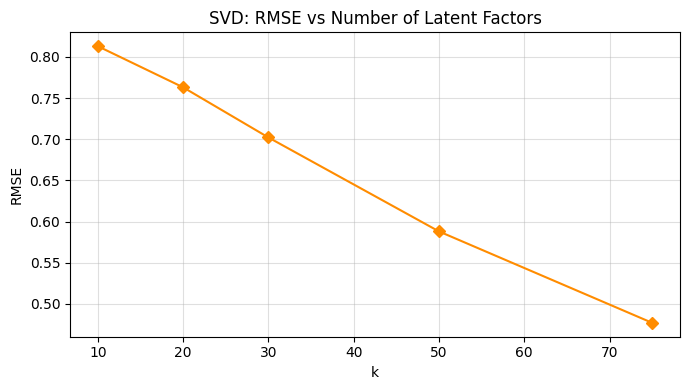

In [41]:
# EXPERIMENT: how does RMSE change with different k (latent factors)?
k_exp    = [10, 20, 30, 50, 75]
rmse_exp = []

for kv in k_exp:
    kv = min(kv, min(R_centered.shape) - 1)
    U_, s_, Vt_ = svds(R_centered, k=kv)
    Rp_         = np.clip(np.dot(np.dot(U_, np.diag(s_)), Vt_) + user_means, 0.5, 5.0)
    tr, pr      = [], []
    for i in range(min(60, R.shape[0])):
        for j, v in enumerate(R[i]):
            if v != 0:
                tr.append(v); pr.append(Rp_[i, j])
    rmse_exp.append(np.sqrt(mean_squared_error(tr, pr)))
    print(f'  k={kv:3d}  RMSE = {rmse_exp[-1]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(k_exp, rmse_exp, marker='D', color='darkorange')
plt.title('SVD: RMSE vs Number of Latent Factors')
plt.xlabel('k'); plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Task 6: SVD with Surprise Library

In [44]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as sp_split
from surprise.model_selection import GridSearchCV
from surprise import accuracy

reader   = Reader(rating_scale=(0.5, 5.0))
sp_data  = Dataset.load_from_df(filtered[['userId', 'movieId', 'rating']], reader)

trainset, testset = sp_split(sp_data, test_size=0.2, random_state=42)

svd_sp   = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_sp.fit(trainset)
preds_sp = svd_sp.test(testset)

rmse_sp  = accuracy.rmse(preds_sp)
print(f'Surprise SVD RMSE: {rmse_sp:.4f}')

RMSE: 0.8448
Surprise SVD RMSE: 0.8448


In [45]:
# hyperparameter search
param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs' : [10, 20],
    'lr_all'   : [0.002, 0.005],
    'reg_all'  : [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(sp_data)

print('Best RMSE  :', gs.best_score['rmse'])
print('Best params:', gs.best_params['rmse'])

Best RMSE  : 0.8406412782931696
Best params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


In [46]:
# train best model on full data
best_svd = gs.best_estimator['rmse']
best_svd.fit(sp_data.build_full_trainset())

def recommend_surprise(user_id, n=10):
    all_mids  = filtered['movieId'].unique()
    rated_ids = filtered[filtered['userId'] == user_id]['movieId'].values
    unrated   = [m for m in all_mids if m not in rated_ids]

    preds     = [(m, best_svd.predict(user_id, m).est) for m in unrated]
    preds.sort(key=lambda x: x[1], reverse=True)

    result = pd.DataFrame(preds[:n], columns=['movieId', 'pred_rating'])
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
    result['pred_rating'] = result['pred_rating'].round(2)

    print(f'\nSurprise SVD: Top {n} for User {user_id}')
    print(result[['title', 'genres', 'pred_rating']].to_string(index=False))
    return result

_ = recommend_surprise(1, n=10)


Surprise SVD: Top 10 for User 1
                                                                      title                     genres  pred_rating
                                             Philadelphia Story, The (1940)       Comedy|Drama|Romance         5.00
                                           Shawshank Redemption, The (1994)                Crime|Drama         5.00
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)                 Comedy|War         5.00
                     Wallace & Gromit: The Best of Aardman Animation (1996) Adventure|Animation|Comedy         5.00
                                                  Lawrence of Arabia (1962)        Adventure|Drama|War         5.00
                              Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)    Drama|Film-Noir|Romance         5.00
                                                      Godfather, The (1972)                Crime|Drama         4.97
                                       

---
# Part 4: Hybrid Recommendation Model
**10 Marks**

## Task 7: Meta-Learning Hybrid Model

Train a machine learning model that blends CBF + CF scores dynamically.

In [47]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")

In [48]:
# precompute helper statistics
movie_avg  = ratings.groupby('movieId')['rating'].mean().to_dict()
user_avg   = ratings.groupby('userId')['rating'].mean().to_dict()

# precompute user profiles for CBF
print('Building user profiles...')
user_profiles = {}
for uid in filtered['userId'].unique()[:100]:
    p = build_user_profile(uid)
    if p is not None:
        user_profiles[uid] = p
print(f'Done. {len(user_profiles)} profiles built.')

Building user profiles...
Done. 100 profiles built.


In [49]:
def meta_features(user_id, movie_id):
    """Return [cbf_score, svd_score, movie_popularity, user_bias]"""
    # CBF
    cbf = 0.0
    if user_id in user_profiles and movie_id in movieid_to_idx.index:
        mvec = tfidf_matrix[movieid_to_idx[movie_id]]
        cbf  = float(cosine_similarity(user_profiles[user_id], mvec)[0][0])

    # SVD
    try:
        svd_score = best_svd.predict(user_id, movie_id).est
    except:
        svd_score = 3.5

    popularity = movie_avg.get(movie_id, 3.5)
    bias       = user_avg.get(user_id,  3.5)

    return [cbf, svd_score, popularity, bias]


# build the training set for the meta-model
print('Building meta-features...')
meta_rows = filtered[filtered['userId'].isin(user_profiles.keys())].sample(
    n=min(3000, len(filtered)), random_state=42
)

X_meta, y_meta = [], []
for _, row in meta_rows.iterrows():
    X_meta.append(meta_features(row['userId'], row['movieId']))
    y_meta.append(row['rating'])

X_meta = np.array(X_meta)
y_meta = np.array(y_meta)
print(f'Meta-dataset: {X_meta.shape[0]} samples')

Building meta-features...
Meta-dataset: 3000 samples


In [50]:
X_tr, X_te, y_tr, y_te = train_test_split(X_meta, y_meta, test_size=0.2, random_state=42)

meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
meta_model.fit(X_tr, y_tr)

y_pred_hybrid  = np.clip(meta_model.predict(X_te), 0.5, 5.0)
rmse_hybrid    = np.sqrt(mean_squared_error(y_te, y_pred_hybrid))

svd_only_preds = np.clip(X_te[:, 1], 0.5, 5.0)
rmse_svd_only  = np.sqrt(mean_squared_error(y_te, svd_only_preds))

print(f'Hybrid model RMSE : {rmse_hybrid:.4f}')
print(f'SVD alone RMSE    : {rmse_svd_only:.4f}')

Hybrid model RMSE : 0.8813
SVD alone RMSE    : 0.8694


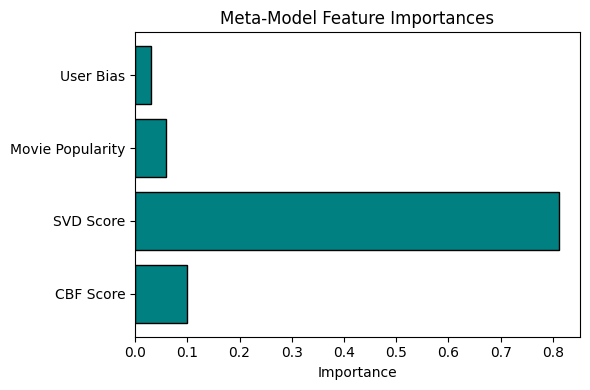

In [51]:
# feature importance
feat_names   = ['CBF Score', 'SVD Score', 'Movie Popularity', 'User Bias']
importances  = meta_model.feature_importances_

plt.figure(figsize=(6, 4))
plt.barh(feat_names, importances, color='teal', edgecolor='black')
plt.title('Meta-Model Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [52]:
# cold-start analysis
cold_users = ratings.groupby('userId').size()
cold_users = cold_users[cold_users <= 5].index.tolist()

print(f'Found {len(cold_users)} cold-start users (<=5 ratings)\n')

Found 0 cold-start users (<=5 ratings)



---
# Part 5: Learning-Based Recommender Systems
**40 Marks**

## Task 8: Content-Based Filtering with a Neural Network

In [53]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TF version:', tf.__version__)

TF version: 2.19.0


In [54]:
# one-hot encode genres for movie feature vectors
all_genres = ['Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
              'Mystery','Romance','Sci-Fi','Thriller','War','Western']

for g in all_genres:
    movies[g] = movies['genres'].str.contains(g).astype(int)

movies['year_norm']      = (movies['year'] - movies['year'].min()) / (movies['year'].max() - movies['year'].min())
movies['year_norm']      = movies['year_norm'].fillna(0)

m_avg = ratings.groupby('movieId')['rating'].mean().rename('avg_rating')
movies = movies.merge(m_avg, on='movieId', how='left')
movies['avg_rating'].fillna(movies['avg_rating'].mean(), inplace=True)
movies['avg_rating_norm'] = (movies['avg_rating'] - 0.5) / 4.5

movie_feat_cols  = all_genres + ['year_norm', 'avg_rating_norm']
movie_feat_dict  = movies.set_index('movieId')[movie_feat_cols].to_dict(orient='index')
print('Movie feature dim:', len(movie_feat_cols))

Movie feature dim: 20


In [55]:
def user_genre_vec(user_id):
    """User feature: avg rating per genre, normalized to 0-1"""
    rated = ratings[ratings['userId'] == user_id].merge(movies, on='movieId', how='inner')
    vec   = []
    for g in all_genres:
        gm = rated[rated[g] == 1]
        vec.append(gm['rating'].mean() / 5.0 if len(gm) > 0 else 0.5)
    return np.array(vec)

print('Computing user genre vectors...')
train_users   = filtered['userId'].unique()[:150]
user_vecs     = {uid: user_genre_vec(uid) for uid in train_users}
print(f'Done. User feature dim: {len(all_genres)}')

Computing user genre vectors...
Done. User feature dim: 18


In [56]:
# build dataset
Xu, Xm, y_nn = [], [], []
nn_data = filtered[filtered['userId'].isin(train_users)]

for _, row in nn_data.iterrows():
    uid, mid, r = row['userId'], row['movieId'], row['rating']
    if mid in movie_feat_dict:
        Xu.append(user_vecs[uid])
        Xm.append(list(movie_feat_dict[mid].values()))
        y_nn.append(r / 5.0)   # normalize to 0-1

Xu   = np.array(Xu)
Xm   = np.array(Xm)
y_nn = np.array(y_nn)

print(f'Samples: {len(y_nn)}, user_dim={Xu.shape[1]}, movie_dim={Xm.shape[1]}')

Samples: 22625, user_dim=18, movie_dim=20


In [57]:
# build the neural network
# user branch
u_input  = keras.Input(shape=(Xu.shape[1],), name='user_input')
u_dense  = layers.Dense(32, activation='relu')(u_input)
u_dense  = layers.Dropout(0.2)(u_dense)
u_emb    = layers.Dense(16, activation='relu', name='user_emb')(u_dense)

# movie branch
m_input  = keras.Input(shape=(Xm.shape[1],), name='movie_input')
m_dense  = layers.Dense(32, activation='relu')(m_input)
m_dense  = layers.Dropout(0.2)(m_dense)
m_emb    = layers.Dense(16, activation='relu', name='movie_emb')(m_dense)

# combine and output
merged   = layers.Concatenate()([u_emb, m_emb])
combined = layers.Dense(32, activation='relu')(merged)
combined = layers.Dropout(0.2)(combined)
output   = layers.Dense(1, activation='sigmoid')(combined)  # 0 to 1

nn_model = keras.Model(inputs=[u_input, m_input], outputs=output)
nn_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        608 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        672 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb (Dense)    │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb (Dense)   │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ user_emb[0][0],   │
│ (Concatenate)       │                   │            │ movie_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,425 (13.38 KB)

 Trainable params: 3,425 (13.38 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
sp  = int(0.8 * len(y_nn))
Xu_tr, Xu_te = Xu[:sp], Xu[sp:]
Xm_tr, Xm_te = Xm[:sp], Xm[sp:]
y_tr_nn, y_te_nn = y_nn[:sp], y_nn[sp:]

early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = nn_model.fit(
    [Xu_tr, Xm_tr], y_tr_nn,
    validation_data=([Xu_te, Xm_te], y_te_nn),
    epochs=50, batch_size=64, callbacks=[early], verbose=1
)

Epoch 1/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0421 - val_loss: 0.0305
Epoch 2/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0378 - val_loss: 0.0294
Epoch 3/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0359 - val_loss: 0.0322
Epoch 4/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0351 - val_loss: 0.0305
Epoch 5/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0339 - val_loss: 0.0332
Epoch 6/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0335 - val_loss: 0.0319
Epoch 7/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0329 - val_loss: 0.0314


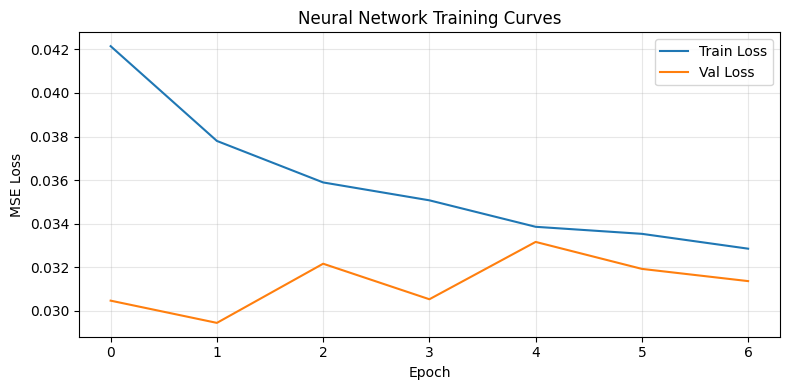

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Neural Network Training Curves')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [60]:
y_pred_nn   = nn_model.predict([Xu_te, Xm_te], verbose=0).flatten() * 5.0
y_true_nn   = y_te_nn * 5.0
rmse_nn     = np.sqrt(mean_squared_error(y_true_nn, y_pred_nn))

print(f'Neural Network RMSE: {rmse_nn:.4f}')
print(f'Surprise SVD RMSE  : {gs.best_score["rmse"]:.4f}')


Neural Network RMSE: 0.8580
Surprise SVD RMSE  : 0.8406


## Task 9: Reinforcement Learning — Multi-Armed Bandit + Q-Learning

In [61]:
# Treat recommendation as a sequential decision problem:
#   Agent recommends a movie -> gets a reward based on the user's actual rating
#   rating >= 4  ->  +1 reward
#   rating <  4  ->  -1 reward
#   no rating    ->   0 (neutral)

rl_movies  = popular_movies[:200].tolist()
rl_users   = active_users[:50].tolist()
rating_lut = filtered.set_index(['userId', 'movieId'])['rating'].to_dict()

def get_reward(uid, mid):
    r = rating_lut.get((uid, mid), None)
    if r is None: return 0
    return 1 if r >= 4.0 else -1

print(f'RL setup: {len(rl_users)} users, {len(rl_movies)} movies')

RL setup: 50 users, 200 movies


In [62]:
class EpsilonGreedy:
    """Epsilon-Greedy multi-armed bandit"""
    def __init__(self, arms, eps=0.1):
        self.arms   = arms
        self.eps    = eps
        self.q      = {a: 0.0 for a in arms}  # estimated reward per arm
        self.counts = {a: 0   for a in arms}

    def choose(self):
        if np.random.random() < self.eps:
            return np.random.choice(self.arms)   # explore
        return max(self.q, key=self.q.get)        # exploit

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.q[arm]      += (reward - self.q[arm]) / self.counts[arm]


class UCBBandit:
    """Upper Confidence Bound bandit"""
    def __init__(self, arms, c=2):
        self.arms   = arms
        self.c      = c
        self.q      = {a: 0.0 for a in arms}
        self.counts = {a: 0   for a in arms}
        self.t      = 0

    def choose(self):
        self.t += 1
        for a in self.arms:
            if self.counts[a] == 0:
                return a   # try each arm at least once
        ucb = {a: self.q[a] + self.c * np.sqrt(np.log(self.t) / self.counts[a]) for a in self.arms}
        return max(ucb, key=ucb.get)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.q[arm]      += (reward - self.q[arm]) / self.counts[arm]


print('Bandit classes defined.')

Bandit classes defined.


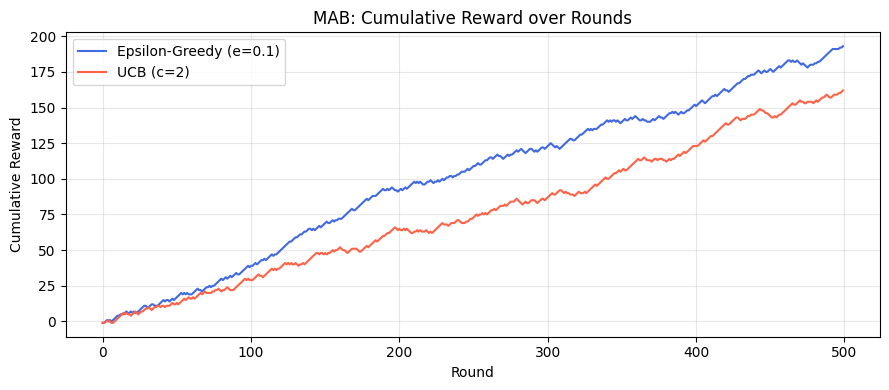

Final cumulative reward — EG: 193,  UCB: 162


In [63]:
# simulate 500 recommendation rounds
T         = 500
arm_pool  = rl_movies[:50]

eg  = EpsilonGreedy(arm_pool, eps=0.1)
ucb = UCBBandit(arm_pool, c=2)

rew_eg, rew_ucb = [], []
np.random.seed(42)

for _ in range(T):
    user = np.random.choice(rl_users)

    m_eg  = eg.choose();  r_eg  = get_reward(user, m_eg);  eg.update(m_eg,   r_eg)
    m_ucb = ucb.choose(); r_ucb = get_reward(user, m_ucb); ucb.update(m_ucb, r_ucb)

    rew_eg.append(r_eg); rew_ucb.append(r_ucb)

plt.figure(figsize=(9, 4))
plt.plot(np.cumsum(rew_eg),  label='Epsilon-Greedy (e=0.1)', color='royalblue')
plt.plot(np.cumsum(rew_ucb), label='UCB (c=2)',               color='tomato')
plt.title('MAB: Cumulative Reward over Rounds')
plt.xlabel('Round'); plt.ylabel('Cumulative Reward')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Final cumulative reward — EG: {sum(rew_eg)},  UCB: {sum(rew_ucb)}')

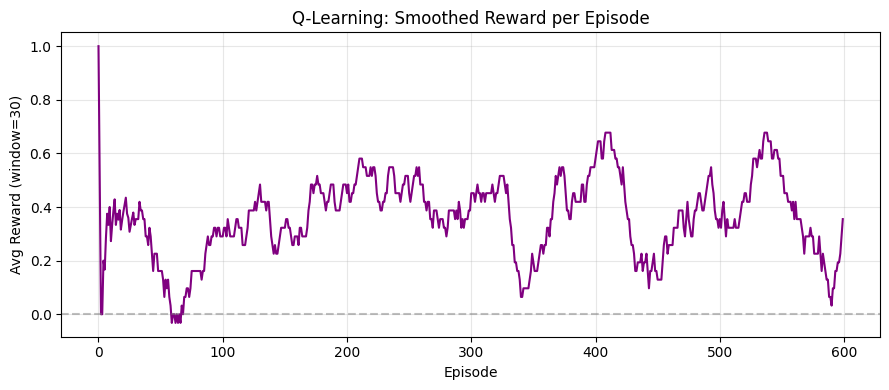

In [64]:
# Q-Learning Agent
# State = user's top genre (18 possible states)
# Action = which of 50 movies to recommend

def get_state(uid):
    """discretize user into a state based on their most-watched genre"""
    ur = ratings[ratings['userId'] == uid].merge(movies, on='movieId', how='inner')
    if ur.empty: return 0
    gcounts = {g: ur[g].sum() for g in all_genres if g in ur.columns}
    if not gcounts: return 0
    return all_genres.index(max(gcounts, key=gcounts.get))


n_states  = len(all_genres)
n_actions = 50
cand_mov  = rl_movies[:n_actions]

Q         = np.random.uniform(-0.01, 0.01, (n_states, n_actions))
alpha_ql  = 0.1
gamma_ql  = 0.9
eps_ql    = 0.15

ql_rewards = []
for ep in range(600):
    uid   = np.random.choice(rl_users)
    state = get_state(uid)

    if np.random.random() < eps_ql:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q[state])

    mid    = cand_mov[action]
    reward = get_reward(uid, mid)

    # Q-learning update
    Q[state, action] += alpha_ql * (reward + gamma_ql * np.max(Q[state]) - Q[state, action])
    ql_rewards.append(reward)

# smoothed reward plot
w = 30
smoothed = [np.mean(ql_rewards[max(0, i-w):i+1]) for i in range(len(ql_rewards))]

plt.figure(figsize=(9, 4))
plt.plot(smoothed, color='purple')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Q-Learning: Smoothed Reward per Episode')
plt.xlabel('Episode'); plt.ylabel('Avg Reward (window=30)')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [65]:
# exploration rate comparison
eg_choices  = [eg.choose()  for _ in range(300)]
ucb_choices = [ucb.choose() for _ in range(300)]

print(f'Unique movies recommended by EG  (300 rounds): {len(set(eg_choices))}')
print(f'Unique movies recommended by UCB (300 rounds): {len(set(ucb_choices))}')

print("""
UCB is naturally more explorative because it actively seeks out
under-explored arms. Epsilon-greedy only explores with a fixed 10% chance.
In production, UCB tends to discover good movies faster.
""")

Unique movies recommended by EG  (300 rounds): 28
Unique movies recommended by UCB (300 rounds): 1

UCB is naturally more explorative because it actively seeks out
under-explored arms. Epsilon-greedy only explores with a fixed 10% chance.
In production, UCB tends to discover good movies faster.



---
# Part 6: Explainability in Recommender Systems
**10 Marks**

In [66]:
import shap
print('SHAP version:', shap.__version__)

SHAP version: 0.49.1


## Task 10: Feature-Based Explanations (Content-Based Filtering)

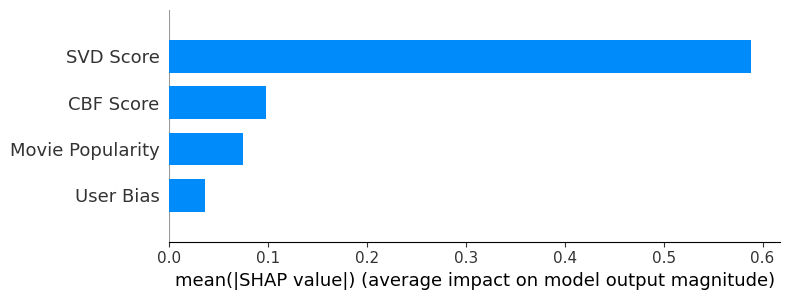

In [67]:
# SHAP on the meta-model (gradient boosting over CBF + CF features)
shap_exp  = shap.TreeExplainer(meta_model)
shap_vals = shap_exp.shap_values(X_te[:100])

feat_names = ['CBF Score', 'SVD Score', 'Movie Popularity', 'User Bias']

shap.summary_plot(shap_vals, X_te[:100], feature_names=feat_names, plot_type='bar')

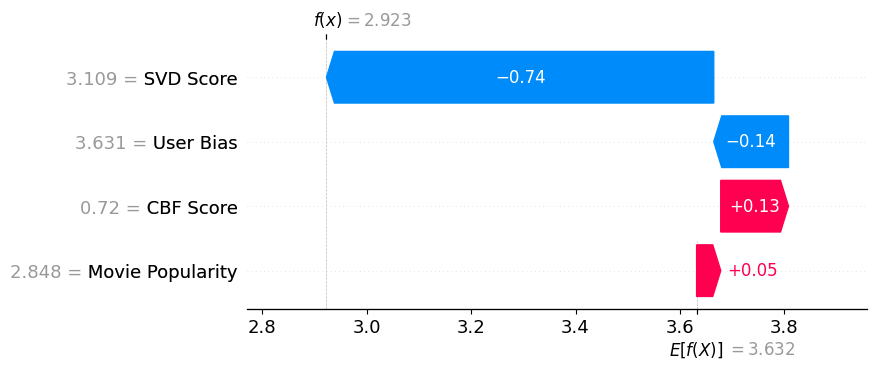

In [68]:
# waterfall plot: explain a single prediction
shap.waterfall_plot(
    shap.Explanation(
        values       = shap_vals[0],
        base_values  = shap_exp.expected_value,
        data         = X_te[0],
        feature_names= feat_names
    )
)

In [69]:
def explain_cbf(user_id, movie_id):
    """Simple human-readable explanation for a content-based recommendation"""
    mrow  = movies[movies['movieId'] == movie_id]
    if mrow.empty: return 'Movie not found.'
    mrow  = mrow.iloc[0]

    yr    = int(mrow['year']) if not np.isnan(mrow['year']) else 'unknown year'

    ur    = ratings[ratings['userId'] == user_id].merge(movies, on='movieId', how='inner')
    gc    = {g: ur[g].sum() for g in all_genres if g in ur.columns}
    top3  = sorted(gc, key=gc.get, reverse=True)[:3]

    overlap = set(mrow['genres'].split('|')) & set(top3)

    lines = [
        f"Why '{mrow['title']}' was recommended to User {user_id}:",
        f"  Movie genres : {mrow['genres'].replace('|', ', ')} ({yr})",
        f"  User's top-3 genres: {', '.join(top3)}",
    ]
    if overlap:
        lines.append(f"  Genre match  : {', '.join(overlap)} -> strong content similarity")
    else:
        lines.append("  No direct genre match; recommended via profile similarity.")

    return '\n'.join(lines)

test_uid = rl_users[0]
test_mid = rl_movies[0]
print(explain_cbf(test_uid, test_mid))

Why 'Forrest Gump (1994)' was recommended to User 414:
  Movie genres : Comedy, Drama, Romance, War (1994)
  User's top-3 genres: Drama, Comedy, Action
  Genre match  : Drama, Comedy -> strong content similarity


## Task 11: Neighborhood-Based Explanations (Collaborative Filtering)

In [70]:
def explain_cf(target_uid, movie_id, k=5):
    if target_uid not in user_sim.index or movie_id not in matrix_sample.columns:
        return 'Cannot generate CF explanation — user or movie not in sample.'

    sims = user_sim[target_uid].drop(target_uid).sort_values(ascending=False)
    liked_neighbors = []
    for nid, sim in sims.items():
        if matrix_sample.loc[nid, movie_id] >= 4.0:
            liked_neighbors.append((nid, sim, matrix_sample.loc[nid, movie_id]))
        if len(liked_neighbors) >= k:
            break

    title = movies[movies['movieId'] == movie_id]['title'].values
    title = title[0] if len(title) > 0 else str(movie_id)

    lines = [f"Why '{title}' was recommended (Collaborative Filtering):"]
    if liked_neighbors:
        lines.append(f"  {len(liked_neighbors)} users similar to User {target_uid} also rated it highly:")
        for nid, sim, rat in liked_neighbors:
            lines.append(f"    User {nid} (similarity={sim:.3f}) gave it {rat}/5")
    else:
        lines.append('  No similar neighbors found who rated this movie highly.')

    return '\n'.join(lines)


print(explain_cf(sample_users[0], matrix_sample.columns[5]))

Why 'Sabrina (1995)' was recommended (Collaborative Filtering):
  5 users similar to User 1 also rated it highly:
    User 90 (similarity=0.822) gave it 4.0/5
    User 58 (similarity=0.352) gave it 5.0/5
    User 32 (similarity=0.331) gave it 4.0/5
    User 117 (similarity=0.168) gave it 4.0/5
    User 43 (similarity=0.111) gave it 5.0/5


## Task 12: Model-Agnostic Explainability with LIME

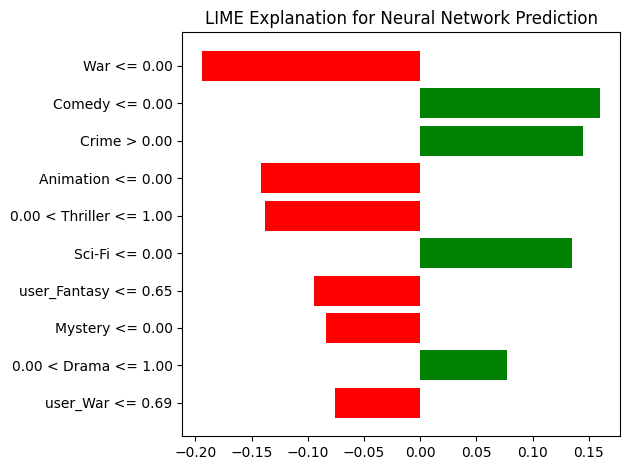


Top influencing features:
  ↓  War <= 0.00: -0.1938
  ↑  Comedy <= 0.00: 0.1599
  ↑  Crime > 0.00: 0.1445
  ↓  Animation <= 0.00: -0.1414
  ↓  0.00 < Thriller <= 1.00: -0.1383
  ↑  Sci-Fi <= 0.00: 0.1352
  ↓  user_Fantasy <= 0.65: -0.0940
  ↓  Mystery <= 0.00: -0.0834
  ↑  0.00 < Drama <= 1.00: 0.0771
  ↓  user_War <= 0.69: -0.0754


In [71]:
from lime import lime_tabular

# combine user + movie features into one vector for LIME
X_comb = np.hstack([Xu, Xm])
comb_feat_names = [f'user_{g}' for g in all_genres] + movie_feat_cols

def nn_pred_fn(X):
    """wrapper: split combined input, run model, scale back to 1-5"""
    u = X[:, :len(all_genres)]
    m = X[:, len(all_genres):]
    return nn_model.predict([u, m], verbose=0).flatten() * 5.0

lime_exp = lime_tabular.LimeTabularExplainer(
    training_data  = X_comb[:sp],
    feature_names  = comb_feat_names,
    mode           = 'regression'
)

# explain first test sample
exp = lime_exp.explain_instance(X_comb[sp], nn_pred_fn, num_features=10)
exp.as_pyplot_figure()
plt.title('LIME Explanation for Neural Network Prediction')
plt.tight_layout()
plt.show()

print('\nTop influencing features:')
for feat, w in exp.as_list():
    print(f'  {"↑" if w > 0 else "↓"}  {feat}: {w:.4f}')

## Task 13: Evaluating Explainability

In [72]:
# Show all three explanation methods for the same (user, movie) pair

e_uid = rl_users[0]
e_mid = rl_movies[0]

minfo = movies[movies['movieId'] == e_mid]
if not minfo.empty:
    print(f"Explaining: '{minfo.iloc[0]['title']}' for User {e_uid}\n")

print('=' * 55)
print('METHOD 1: Content-Based (Genre Profile)')
print('=' * 55)
print(explain_cbf(e_uid, e_mid))

print()
print('=' * 55)
print('METHOD 2: Collaborative Filtering (Neighbors)')
print('=' * 55)
if e_uid in user_sim.index and e_mid in matrix_sample.columns:
    print(explain_cf(e_uid, e_mid))
else:
    print('(User or movie not in CF sample.)')

print()
print('=' * 55)
print('METHOD 3: Meta-Model (SHAP feature attribution)')
print('=' * 55)
print('See SHAP waterfall plot above — it shows how much each of')
print('CBF score, SVD score, popularity, and user bias contributed.')

Explaining: 'Forrest Gump (1994)' for User 414

METHOD 1: Content-Based (Genre Profile)
Why 'Forrest Gump (1994)' was recommended to User 414:
  Movie genres : Comedy, Drama, Romance, War (1994)
  User's top-3 genres: Drama, Comedy, Action
  Genre match  : Drama, Comedy -> strong content similarity

METHOD 2: Collaborative Filtering (Neighbors)
(User or movie not in CF sample.)

METHOD 3: Meta-Model (SHAP feature attribution)
See SHAP waterfall plot above — it shows how much each of
CBF score, SVD score, popularity, and user bias contributed.


In [73]:
# Final summary of all methods
summary = pd.DataFrame({
    'Method': [
        'TF-IDF CBF',
        'User-Based CF',
        'Item-Based CF',
        'SVD (scipy)',
        'SVD (Surprise)',
        'Hybrid Meta-Model',
        'Neural Network',
        'RL (MAB + Q-Learning)'
    ],
    'Needs Ratings': ['No','Yes','Yes','Yes','Yes','Yes','Yes','Simulated'],
    'Scalable': ['Yes','No','Yes','Yes','Yes','Yes','Yes','Yes'],
    'Cold-Start': ['Good','Poor','Poor','Poor','Poor','Medium','Medium','Explores'],
    'Explainable': ['High','High','Medium','Low','Low','Medium','Low','Low']
})

print(summary.to_string(index=False))

               Method Needs Ratings Scalable Cold-Start Explainable
           TF-IDF CBF            No      Yes       Good        High
        User-Based CF           Yes       No       Poor        High
        Item-Based CF           Yes      Yes       Poor      Medium
          SVD (scipy)           Yes      Yes       Poor         Low
       SVD (Surprise)           Yes      Yes       Poor         Low
    Hybrid Meta-Model           Yes      Yes     Medium      Medium
       Neural Network           Yes      Yes     Medium         Low
RL (MAB + Q-Learning)     Simulated      Yes   Explores         Low
